# CNN-VAE for Anomaly Detection Using Toy Car Audio

**Purpose:** This notebook follows the same staged workflow as `03-CNN_AE.ipynb`, while keeping CNN-VAE model logic and H100/H200-oriented training settings.

## 1. Imports and Setup Notes

Cells 1 and 2 are kept as your online setup block. The following sections focus on reusable dataset/model/tuning/evaluation flow.

In [ ]:
import os
import glob
import random

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve
from torch.utils.data import DataLoader, Dataset, Subset

from helpers.helper_npy_data import (
    UnifiedNPYDataset,
    compute_target_T_from_npy,
    split_indices,
)

from helpers.helper_eval import (
    downsample_anomaly_scores,
    evaluate_scores,
    find_best_f1_threshold,
    get_reconstruction_scores,
    plot_one_reconstruction,
)

## 2. Paths and Configuration

Set experiment constants and output paths in one place, similar to the CNN baseline notebook style.

In [ ]:

DATA_BASE_PATH = "./data"
CASES = ["case1", "case2", "case3", "case4"]
BEST_MODEL_PATH = "./outputs/models/best_CNN_VAE_hist.pth"
STUDY_SAVE_PATH = "./outputs/studies/cnn_vae_study.pkl"

# Fast tuning keeps trial 0 from feeling stuck on large memmapped datasets.
FAST_TUNE = False
TUNE_MAX_TRAIN_SAMPLES = 256 if FAST_TUNE else 512

os.makedirs("./outputs/models", exist_ok=True)
os.makedirs("./outputs/studies", exist_ok=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

DATA_BASE_PATH: ./data
BEST_MODEL_PATH: ./outputs/models/best_CNN_VAE_hist.pth
STUDY_SAVE_PATH: ./outputs/studies/cnn_vae_study.pkl
FAST_TUNE: False
TUNE_MAX_TRAIN_SAMPLES: 512


## 3. Data Preprocessing

This stage prepares a unified dataset from IND/CNT_SEG `.npy` files and applies robust path resolution for local or cloud runs.

In [3]:
# Estimate a robust common length from IND normal data, then build the unified dataset.
base_npy_path = DATA_BASE_PATH
target_T = compute_target_T_from_npy(
    base_path=base_npy_path,
    cases=CASES,
 )

npy_dataset = UnifiedNPYDataset(
    base_path=base_npy_path,
    cases=CASES,
    target_T=target_T,
    use_ind=True,
    use_cnt=True,
    include_anomaly=True,
    stride_ratio=5.0,
 )
print(len(npy_dataset), target_T)

[INFO] target_T from IND: 582
[INFO] min=582, max=582
[INFO] IND normal: 5400
[INFO] CNT candidates (windows): 15678
[INFO] CNT sampled: 5400
[INFO] IND anomaly: 1058
[WARN] Dropped short samples (< target_T): 1
[INFO] Total samples: 11858
11858 582


## 4. Dataset Splitting and Loader Setup

This section builds train/validation/test splits and then constructs case-aware loaders for per-case and all-case evaluation.

In [4]:
import random
from torch.utils.data import Subset

random.seed(42)

# Separate indices

normal_indices = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 0]
anom_indices   = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 1]

# split normal into IND / CNT
ind_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is None]
cnt_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is not None]

# Shuffle separately
random.shuffle(ind_indices)
random.shuffle(cnt_indices)

# Stratified split
ind_train, ind_val, ind_test = split_indices(ind_indices)
cnt_train, cnt_val, cnt_test = split_indices(cnt_indices)

# merge back
train_idx        = ind_train + cnt_train
val_normal_idx   = ind_val + cnt_val
test_normal_idx  = ind_test + cnt_test

# shuffle merged splits
random.shuffle(train_idx)
random.shuffle(val_normal_idx)
random.shuffle(test_normal_idx)

# ANOMALY split (50 / 50)
random.shuffle(anom_indices)

m = len(anom_indices)
val_anom_idx  = anom_indices[:m // 2]
test_anom_idx = anom_indices[m // 2:]

# DATASETS
train_dataset = Subset(npy_dataset, train_idx)

val_normal = Subset(npy_dataset, val_normal_idx)
val_anom   = Subset(npy_dataset, val_anom_idx)

test_normal = Subset(npy_dataset, test_normal_idx)
test_anom   = Subset(npy_dataset, test_anom_idx)

## 5. Model

The model is a CNN-VAE: convolutional encoder, latent reparameterization, and convolutional decoder for reconstruction-based anomaly scoring.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_VAE(nn.Module):
    """
    Convolutional Variational Autoencoder (CNN-VAE) for spectrogram reconstruction.

    Key idea:
    - Use convolutional layers to extract spatial (time–frequency) features
    - Learn a probabilistic latent representation (mean + variance)
    - Sample from this distribution using the reparameterization trick
    - Reconstruct input via a convolutional decoder

    Advantage over standard AE:
    - Enforces structured latent space (smooth, continuous)
    - Better generalization to unseen/anomalous data

    Limitation:
    - Reconstruction may be blurrier due to stochastic sampling
    """

    def __init__(self, channels, latent_dim, input_shape=(4, 64, 64), dropout=0.0):
        """
        Args:
            channels: List of output channels for encoder layers
                      e.g. [32, 64, 128]
            latent_dim: Dimension of latent vector z
            input_shape: Input spectrogram shape (C, H, W)
            dropout: Dropout probability for regularization
        """
        super().__init__()

        # Encoder (Convolutional Feature Extractor)
        # Purpose:
        #   Extract hierarchical spatial features from spectrogram
        #   Reduce spatial resolution via strided convolutions

        encoder = []
        in_c = input_shape[0]  # number of input channels (e.g., 4)

        for c in channels:
            # Conv layer:
            # - kernel=3 -> capture local patterns
            # - stride=2 -> downsample (reduce spatial size)
            # - padding=1 -> preserve alignment
            encoder.append(nn.Conv2d(in_c, c, kernel_size=3, stride=2, padding=1))

            # Non-linearity
            encoder.append(nn.ReLU())

            # Dropout for regularization (optional)
            if dropout > 0:
                encoder.append(nn.Dropout2d(dropout))

            in_c = c  # update channel size for next layer

        self.encoder = nn.Sequential(*encoder)

        # Infer encoded feature shape dynamically
        # We pass a dummy tensor through encoder to compute:
        #   - output feature map shape
        #   - flattened dimension for fully connected layers

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)  # [1, C, H, W]
            enc_out = self.encoder(dummy)

        # Shape of encoded feature map (excluding batch dimension)
        self.enc_shape = enc_out.shape[1:]  # e.g. [128, 8, 8]

        # Total flattened size
        self.flatten_dim = enc_out.numel()  # e.g. 128*8*8

        # Latent Space (VAE)
        # Instead of a single vector, we learn:
        #   μ (mean) and log(σ²) (log-variance)

        # Map encoded features -> mean vector
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)

        # Map encoded features -> log-variance vector
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Map latent vector back -> flattened feature space
        self.fc_dec = nn.Linear(latent_dim, self.flatten_dim)

        # Optional dropout on latent vector
        self.dropout_fc = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Decoder (Transpose Convolutions)
        # Purpose:
        #   Reconstruct spatial structure from compressed features
        #   Gradually upsample using ConvTranspose2d

        decoder = []
        in_c = self.enc_shape[0]  # start from encoded channels

        # Reverse channel progression (mirror of encoder)
        for c in reversed(channels[:-1]):
            decoder.append(nn.ConvTranspose2d(
                in_c, c,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1  # ensures correct upsampling size
            ))
            decoder.append(nn.ReLU())

            if dropout > 0:
                decoder.append(nn.Dropout2d(dropout))

            in_c = c

        # Final layer: restore original number of channels
        decoder.append(nn.ConvTranspose2d(
            in_c, input_shape[0],
            kernel_size=3,
            stride=2,
            padding=1,
            output_padding=1
        ))

        self.decoder = nn.Sequential(*decoder)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:
        - Sample z ~ N(mu, sigma^2)
        - Rewrite as: z = mu + eps * sigma, eps ~ N(0, 1)

        This allows gradients to flow through stochastic sampling.
        """
        std = torch.exp(0.5 * logvar)  # convert log-variance -> std
        eps = torch.randn_like(std)    # sample noise
        return mu + eps * std          # reparameterized sample

    def forward(self, x, return_latent=False):
        """
        Forward pass of CNN-VAE.

        Steps:
        1. Encode input into feature map
        2. Flatten and compute μ and logσ²
        3. Sample latent vector z
        4. Decode z back into feature map
        5. Reconstruct full spectrogram
        """

        # Step 1: Encode input
        h = self.encoder(x)  # [B, C', H', W']

        # Flatten for fully connected layers
        h = h.view(h.size(0), -1)

        # Step 2: Compute latent distribution parameters
        mu = self.fc_mu(h)         # mean
        logvar = self.fc_logvar(h) # log-variance

        # Step 3: Sample latent vector
        z = self.reparameterize(mu, logvar)

        # Optional dropout
        z = self.dropout_fc(z)

        # Step 4: Decode latent vector
        h_dec = self.fc_dec(z)

        # Reshape back to feature map
        h_dec = h_dec.view(h_dec.size(0), *self.enc_shape)

        # Apply transpose conv decoder
        out = self.decoder(h_dec)

        # Step 5: Resize to exact input size
        # Due to stride/transpose operations, output size may not match exactly
        # Use interpolation to ensure exact match
        recon = F.interpolate(
            out,
            size=x.shape[-2:],  # match original H, W
            mode="bilinear",
            align_corners=False
        )

        # Output
        if return_latent:
            # Return additional latent info for KL loss
            return recon, mu, logvar

        return recon

In [ ]:
from torch.utils.data import DataLoader, Subset
import gc
import os
import random

# Toggle this to switch between balanced and aggressive H100/H200 training presets.
FAST_H100 = True

# Notebook-safe mode is the stable default for long Optuna runs.
SAFE_NOTEBOOK_DATALOADER = False

if FAST_H100:
    NUM_WORKERS = min(4, os.cpu_count() or 4)
else:
    NUM_WORKERS = min(2, os.cpu_count() or 4)

if SAFE_NOTEBOOK_DATALOADER:
    NUM_WORKERS = 0

ENABLE_TORCH_COMPILE = False

# Fast DataLoader settings for GPU training
USE_CUDA = torch.cuda.is_available()

def make_loader(dataset, batch_size, shuffle=False):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": USE_CUDA,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = False
        kwargs["prefetch_factor"] = 2
    return DataLoader(dataset, **kwargs)

# CASE MAPPING (local, robust for IND/CNT_SEG/CNT)
def infer_case_from_path_local(path: str) -> str:
    parts = path.replace("\\", "/").split("/")

    for anchor in ("IND", "CNT_SEG", "CNT"):
        if anchor in parts:
            anchor_idx = parts.index(anchor)
            if anchor_idx + 1 < len(parts):
                return parts[anchor_idx + 1]

    filename = parts[-1]
    if "_seg" in filename:
        return filename.split("_seg", 1)[0]

    return "unknown"

sample_cases = [infer_case_from_path_local(p) for (p, _, _) in npy_dataset.samples]

# TRAIN LOADER (NORMAL ONLY)
train_loader = make_loader(train_dataset, batch_size=8, shuffle=True)

# VALIDATION/TEST LOADERS
def make_val_loaders(selected_cases, batch_size=8, anom_ratio=0.05):
    selected_cases = set(selected_cases)

    sel_val_normal_idx = [
        i for i in val_normal_idx
        if sample_cases[i] in selected_cases
    ]
    sel_val_anom_idx = [
        i for i in val_anom_idx
        if sample_cases[i] in selected_cases
    ]

    n_normal = len(sel_val_normal_idx)
    target_anom = max(1, int(n_normal * anom_ratio))

    if len(sel_val_anom_idx) > target_anom:
        sel_val_anom_idx = random.sample(sel_val_anom_idx, target_anom)

    val_normal_subset = Subset(npy_dataset, sel_val_normal_idx)
    val_anom_subset = Subset(npy_dataset, sel_val_anom_idx)

    val_normal_loader = make_loader(val_normal_subset, batch_size=batch_size, shuffle=False)
    val_anom_loader = make_loader(val_anom_subset, batch_size=batch_size, shuffle=False)

    return val_normal_loader, val_anom_loader, len(sel_val_normal_idx), len(sel_val_anom_idx)

def make_test_loaders(selected_cases, batch_size=8, anom_ratio=0.05):
    selected_cases = set(selected_cases)

    sel_test_normal_idx = [
        i for i in test_normal_idx
        if sample_cases[i] in selected_cases
    ]
    sel_test_anom_idx = [
        i for i in test_anom_idx
        if sample_cases[i] in selected_cases
    ]

    n_normal = len(sel_test_normal_idx)
    target_anom = max(1, int(n_normal * anom_ratio))

    if len(sel_test_anom_idx) > target_anom:
        sel_test_anom_idx = random.sample(sel_test_anom_idx, target_anom)

    test_normal_subset = Subset(npy_dataset, sel_test_normal_idx)
    test_anom_subset = Subset(npy_dataset, sel_test_anom_idx)

    test_normal_loader = make_loader(test_normal_subset, batch_size=batch_size, shuffle=False)
    test_anom_loader = make_loader(test_anom_subset, batch_size=batch_size, shuffle=False)

    return test_normal_loader, test_anom_loader, len(sel_test_normal_idx), len(sel_test_anom_idx)

# CASE SCOPES
TRAIN_CASES = ["case1", "case2", "case3", "case4"]

VAL_CASE_SCOPES = {
    "case1_only": ["case1"],
    "case2_only": ["case2"],
    "case3_only": ["case3"],
    "case4_only": ["case4"],
    "all_cases": TRAIN_CASES,
}

# BUILD VAL LOADERS
val_loaders = {}

for scope_name, scope_cases in VAL_CASE_SCOPES.items():
    vn_loader, va_loader, n_normal, n_anom = make_val_loaders(scope_cases)

    val_loaders[scope_name] = {
        "val_normal_loader": vn_loader,
        "val_anom_loader": va_loader,
        "n_normal": n_normal,
        "n_anom": n_anom,
    }

    print(f"[VAL] {scope_name}: normal={n_normal}, anomaly={n_anom}")

test_loaders = {}

for scope_name, scope_cases in VAL_CASE_SCOPES.items():
    tn_loader, ta_loader, n_normal, n_anom = make_test_loaders(scope_cases)

    test_loaders[scope_name] = {
        "test_normal_loader": tn_loader,
        "test_anom_loader": ta_loader,
        "n_normal": n_normal,
        "n_anom": n_anom,
    }

    print(f"[TEST] {scope_name}: normal={n_normal}, anomaly={n_anom}")

# default (for tuning)
val_normal_loader = val_loaders["all_cases"]["val_normal_loader"]
val_anom_loader = val_loaders["all_cases"]["val_anom_loader"]
test_normal_loader = test_loaders["all_cases"]["test_normal_loader"]
test_anom_loader = test_loaders["all_cases"]["test_anom_loader"]

[VAL] case1_only: normal=344, anomaly=17
[VAL] case2_only: normal=251, anomaly=12
[VAL] case3_only: normal=261, anomaly=13
[VAL] case4_only: normal=224, anomaly=11
[VAL] all_cases: normal=1080, anomaly=54
[TEST] case1_only: normal=361, anomaly=18
[TEST] case2_only: normal=256, anomaly=12
[TEST] case3_only: normal=230, anomaly=11
[TEST] case4_only: normal=233, anomaly=11
[TEST] all_cases: normal=1080, anomaly=54


## 6. Fine Tuning

Optuna searches CNN-VAE hyperparameters using H100/H200-friendly settings (AMP, TF32, and optional compile toggle).

In [ ]:
# H100-friendly speed settings
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

TUNE_SCOPE = "all_cases"

if FAST_H100:
    N_TRIALS = 30
    TUNE_EPOCHS = 30
    FINAL_EPOCHS = 30
    BATCH_SIZE_CANDIDATES = [64, 128, 256]
else:
    N_TRIALS = 30
    TUNE_EPOCHS = 30
    FINAL_EPOCHS = 30
    BATCH_SIZE_CANDIDATES = [32, 64, 128]

USE_AMP = device.type == "cuda"
USE_COMPILE = ENABLE_TORCH_COMPILE and device.type == "cuda" and hasattr(torch, "compile")

def objective(trial):
    print(f"\n=== Trial {trial.number} ===")
    train_loader = None
    tune_train_dataset = None
    model = None
    optimizer = None
    scaler = None

    try:
        if len(train_idx) > TUNE_MAX_TRAIN_SAMPLES:
            tune_train_idx = random.sample(train_idx, TUNE_MAX_TRAIN_SAMPLES)
        else:
            tune_train_idx = list(train_idx)
        tune_train_dataset = Subset(npy_dataset, tune_train_idx)
        depth = trial.suggest_int("depth", 2, 3)
        base_channels = trial.suggest_categorical("base_channels", [8, 16, 32])
        channels = [base_channels * (2 ** i) for i in range(depth)]
        latent_dim = trial.suggest_categorical("latent_dim", [8, 16, 32])

        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.0, 0.3)
        beta = trial.suggest_float("beta", 1e-5, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", BATCH_SIZE_CANDIDATES)
        noise_std = trial.suggest_float("noise_std", 0.0, 0.05)
        score_type = trial.suggest_categorical("score_type", ["l1", "l2"])

        train_loader = make_loader(tune_train_dataset, batch_size=batch_size, shuffle=True)
        if len(train_loader) == 0:
            raise RuntimeError("Empty training loader for this trial")

        sample_x, _ = next(iter(train_loader))
        input_shape = sample_x.shape[1:]
        model = CNN_VAE(channels, latent_dim, input_shape, dropout=dropout).to(device)
        if USE_COMPILE:
            model = torch.compile(model)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

        def recon_loss_fn(recon, x):
            if score_type == "l1":
                return torch.mean(torch.abs(recon - x))
            return torch.mean((recon - x) ** 2)

        def vae_loss(recon, x, mu, logvar):
            recon_loss = recon_loss_fn(recon, x)
            kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            return recon_loss + beta * kl

        def reconstruction_errors(loader):
            model.eval()
            errors = []
            with torch.no_grad():
                for x, _ in loader:
                    x = x.to(device, non_blocking=True)
                    recon = model(x)
                    if score_type == "l1":
                        err = torch.mean(torch.abs(x - recon), dim=(1, 2, 3))
                    else:
                        err = torch.mean((x - recon) ** 2, dim=(1, 2, 3))
                    errors.extend(err.detach().cpu().numpy())
            return np.array(errors)

        def compute_pr_auc(vn_loader, va_loader):
            normal_scores = reconstruction_errors(vn_loader)
            anom_scores = reconstruction_errors(va_loader)
            if len(normal_scores) == 0 or len(anom_scores) == 0:
                return 0.5, normal_scores, anom_scores
            y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anom_scores))])
            y_score = np.concatenate([normal_scores, anom_scores])
            if len(np.unique(y_true)) < 2:
                return 0.5, normal_scores, anom_scores
            return average_precision_score(y_true, y_score), normal_scores, anom_scores

        for epoch in range(TUNE_EPOCHS):
            model.train()
            for x, _ in train_loader:
                x = x.to(device, non_blocking=True)
                x_noisy = x + noise_std * torch.randn_like(x) if noise_std > 0 else x

                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    recon, mu, logvar = model(x_noisy, return_latent=True)
                    loss = vae_loss(recon, x, mu, logvar)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            if epoch % 2 == 0:
                vn_loader = val_loaders[TUNE_SCOPE]["val_normal_loader"]
                va_loader = val_loaders[TUNE_SCOPE]["val_anom_loader"]
                pr_auc, _, _ = compute_pr_auc(vn_loader, va_loader)
                trial.report(pr_auc, epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()

        vn_loader = val_loaders[TUNE_SCOPE]["val_normal_loader"]
        va_loader = val_loaders[TUNE_SCOPE]["val_anom_loader"]
        pr_auc, normal_scores, anom_scores = compute_pr_auc(vn_loader, va_loader)
        gap = float(np.mean(anom_scores) - np.mean(normal_scores)) if len(normal_scores) and len(anom_scores) else 0.0
        trial.set_user_attr(f"{TUNE_SCOPE}_pr_auc", float(pr_auc))
        trial.set_user_attr("gap", gap)
        print(f"Validation PR AUC ({TUNE_SCOPE}): {pr_auc:.4f}")

        return float(pr_auc)

    except (AssertionError, RuntimeError, ValueError) as exc:
        print(f"[TRIAL {trial.number}] skipped after {type(exc).__name__}: {exc}")
        trial.set_user_attr("failure", f"{type(exc).__name__}: {exc}")
        raise optuna.TrialPruned()

    finally:
        del train_loader, tune_train_dataset, model, optimizer, scaler
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)

print("[BEST] AUC:", study.best_value)
print("[BEST] params:", study.best_params)
print("[BEST] gap:", study.best_trial.user_attrs.get("gap", None))

[I 2026-04-18 21:47:51,033] A new study created in memory with name: no-name-456abd54-0990-4e94-9589-8237c58638ce


cuda

=== Trial 0 ===
Validation PR AUC (all_cases): 0.0658


[I 2026-04-18 21:48:34,742] Trial 0 finished with value: 0.06581993492626237 and parameters: {'depth': 2, 'base_channels': 8, 'latent_dim': 16, 'lr': 0.0013450819989718518, 'weight_decay': 2.424318064264127e-07, 'dropout': 0.03641274769150138, 'beta': 0.004372255345809954, 'batch_size': 64, 'noise_std': 0.002266178580421241, 'score_type': 'l2'}. Best is trial 0 with value: 0.06581993492626237.



=== Trial 1 ===
Validation PR AUC (all_cases): 0.0388


[I 2026-04-18 21:49:23,436] Trial 1 finished with value: 0.03882881063812757 and parameters: {'depth': 2, 'base_channels': 16, 'latent_dim': 16, 'lr': 0.00014307400333153164, 'weight_decay': 0.00017633369758910807, 'dropout': 0.13890081623087722, 'beta': 3.7561857826689336e-05, 'batch_size': 256, 'noise_std': 0.04173797809103777, 'score_type': 'l2'}. Best is trial 0 with value: 0.06581993492626237.


...


=== Trial 28 ===


[I 2026-04-18 21:58:38,645] Trial 28 pruned. 



=== Trial 29 ===


[I 2026-04-18 21:58:42,150] Trial 29 pruned. 


[BEST] AUC: 0.1230735671587572
[BEST] params: {'depth': 2, 'base_channels': 16, 'latent_dim': 8, 'lr': 0.0014995925727849125, 'weight_decay': 1.4078596710706223e-06, 'dropout': 0.12730587652924816, 'beta': 0.0003631129743204386, 'batch_size': 64, 'noise_std': 0.018760960912172768, 'score_type': 'l2'}
[BEST] gap: 0.0009369272738695145


Saved study to: ./outputs/studies/cnn_vae_study.pkl
[INFO] Plotly visualization skipped: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.


/tmp/ipykernel_1082/2365442642.py:22: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  vis_mpl.plot_optimization_history(study)


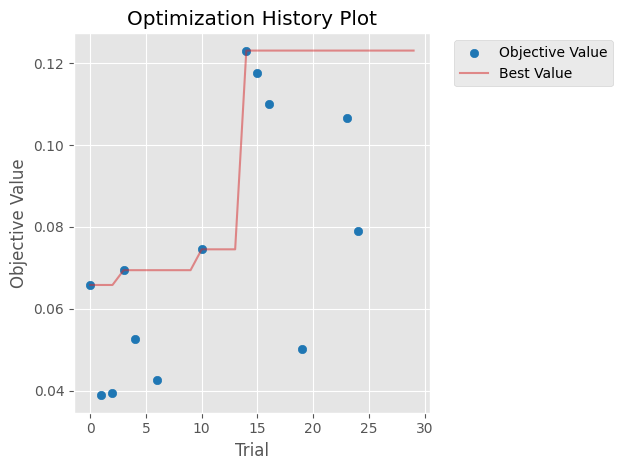

/tmp/ipykernel_1082/2365442642.py:25: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis_mpl.plot_param_importances(study)


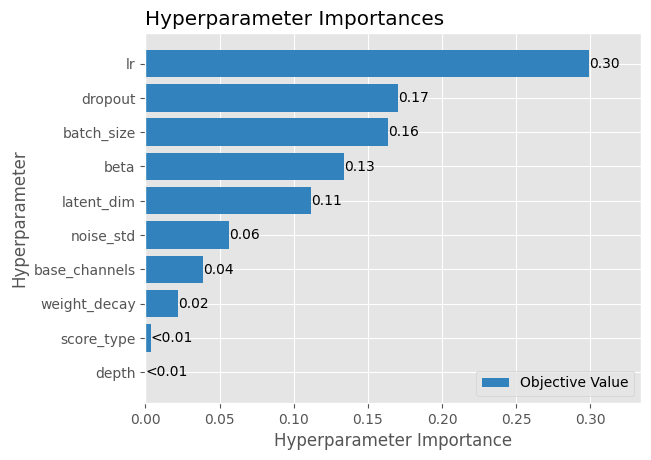

In [8]:
# Save Optuna study (.pkl) and visualize tuning results
import pickle
import optuna.visualization.matplotlib as vis_mpl
import matplotlib.pyplot as plt

os.makedirs(os.path.dirname(STUDY_SAVE_PATH), exist_ok=True)

with open(STUDY_SAVE_PATH, 'wb') as f:
    pickle.dump(study, f)

print(f"Saved study to: {STUDY_SAVE_PATH}")

# Interactive Plotly charts (if available)
try:
    import optuna.visualization as vis
    vis.plot_optimization_history(study).show()
    vis.plot_param_importances(study).show()
except Exception as exc:
    print(f"[INFO] Plotly visualization skipped: {exc}")

# Matplotlib charts (always useful in notebooks)
vis_mpl.plot_optimization_history(study)
plt.show()

vis_mpl.plot_param_importances(study)
plt.show()

## 7. Training the model using the optimal hyperparams

After tuning, rebuild CNN-VAE with best parameters and train a final checkpoint.

In [9]:
# Step 1: rebuild model with best params
best_params = study.best_params
depth = best_params["depth"]
base_channels = best_params["base_channels"]
channels = [base_channels * (2 ** i) for i in range(depth)]
latent_dim = best_params["latent_dim"]
dropout = best_params["dropout"]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sample_x, _ = next(iter(train_loader))
input_shape = sample_x.shape[1:]
model = CNN_VAE(channels, latent_dim, input_shape, dropout).to(device)

In [10]:
# Step 2: train FINAL model

train_loader = make_loader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

USE_AMP = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

beta = best_params.get("beta", 1e-4)
score_type = best_params["score_type"]
train_loss_hist = []
val_loss_hist = []

def recon_loss_fn(recon, x):
    if score_type == "l1":
        return torch.mean(torch.abs(recon - x))
    return torch.mean((recon - x) ** 2)

def vae_loss(recon, x, mu, logvar):
    recon_loss = recon_loss_fn(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl

for epoch in range(FINAL_EPOCHS):
    # TRAIN
    model.train()
    train_loss = 0.0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)

        if best_params["noise_std"] > 0:
            x_noisy = x + best_params["noise_std"] * torch.randn_like(x)
        else:
            x_noisy = x

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            recon, mu, logvar = model(x_noisy, return_latent=True)
            loss = vae_loss(recon, x, mu, logvar)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_loss_hist.append(train_loss)

    # VALIDATION (normal only)
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for x, _ in val_normal_loader:
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                recon, mu, logvar = model(x, return_latent=True)
                val_loss += vae_loss(recon, x, mu, logvar).item()

    val_loss /= len(val_normal_loader)
    val_loss_hist.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

torch.save(model.state_dict(), BEST_MODEL_PATH)
print(f"Saved best model to: {BEST_MODEL_PATH}")

Epoch 1: Train=0.0796, Val=0.0119
Epoch 2: Train=0.0136, Val=0.0076
Epoch 3: Train=0.0109, Val=0.0055
Epoch 4: Train=0.0094, Val=0.0051
Epoch 5: Train=0.0087, Val=0.0054
Epoch 6: Train=0.0081, Val=0.0046
Epoch 7: Train=0.0078, Val=0.0044
Epoch 8: Train=0.0075, Val=0.0043
Epoch 9: Train=0.0073, Val=0.0046
Epoch 10: Train=0.0070, Val=0.0041
Epoch 11: Train=0.0069, Val=0.0042
Epoch 12: Train=0.0070, Val=0.0041
Epoch 13: Train=0.0068, Val=0.0042
Epoch 14: Train=0.0066, Val=0.0040
Epoch 15: Train=0.0066, Val=0.0041
Epoch 16: Train=0.0065, Val=0.0040
Epoch 17: Train=0.0064, Val=0.0041
Epoch 18: Train=0.0065, Val=0.0041
Epoch 19: Train=0.0065, Val=0.0045
Epoch 20: Train=0.0065, Val=0.0040
Epoch 21: Train=0.0064, Val=0.0039
Epoch 22: Train=0.0064, Val=0.0040
Epoch 23: Train=0.0063, Val=0.0039
Epoch 24: Train=0.0064, Val=0.0039
Epoch 25: Train=0.0064, Val=0.0039
Epoch 26: Train=0.0063, Val=0.0040
Epoch 27: Train=0.0063, Val=0.0039
Epoch 28: Train=0.0064, Val=0.0040
Epoch 29: Train=0.0063, Val=0

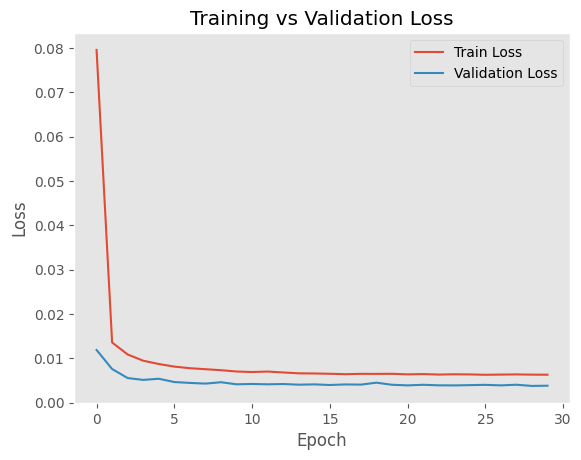

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

## 8. Model Evaluation

Compute a validation threshold and report per-case test PR-AUC/F1/gap metrics.

In [12]:
# Step 3: compute validation threshold (F1) using helper functions
val_normal_scores = get_reconstruction_scores(
    model,
    val_normal_loader,
    device,
    score_type=best_params["score_type"],
)
val_anom_scores = get_reconstruction_scores(
    model,
    val_anom_loader,
    device,
    score_type=best_params["score_type"],
)

if len(val_normal_scores) == 0 or len(val_anom_scores) == 0:
    y_score = np.concatenate([val_normal_scores, val_anom_scores])
    best_threshold = float(np.median(y_score)) if len(y_score) > 0 else 0.0
    print("[WARN] Validation split is empty; using median score as threshold.")
else:
    best_threshold = find_best_f1_threshold(val_normal_scores, val_anom_scores)

print("Best threshold:", best_threshold)

Best threshold: 0.005228939466178417


In [13]:
print("\n=== Per-case Test Results ===")

all_normal_scores = []
all_anom_scores = []

for scope_name, loaders in test_loaders.items():
    normal_scores = get_reconstruction_scores(
        model,
        loaders["test_normal_loader"],
        device,
        score_type=best_params["score_type"],
    )
    anom_scores = get_reconstruction_scores(
        model,
        loaders["test_anom_loader"],
        device,
        score_type=best_params["score_type"],
    )

    if len(normal_scores) == 0 or len(anom_scores) == 0:
        print(f"{scope_name}: skipped because one split is empty")
        continue

    # Use full anomaly set per case for stable per-case reporting.
    anom_scores = downsample_anomaly_scores(normal_scores, anom_scores, anom_ratio=1.0)

    if scope_name != "all_cases":
        all_normal_scores.extend(normal_scores)
        all_anom_scores.extend(anom_scores)

    pr_auc, f1, gap = evaluate_scores(normal_scores, anom_scores, best_threshold)
    print(f"{scope_name}: PR-AUC={pr_auc:.4f}, F1={f1:.4f}, Gap={gap:.4f}")


=== Per-case Test Results ===
case1_only: PR-AUC=0.6482, F1=0.1905, Gap=0.0015
case2_only: PR-AUC=0.9881, F1=0.5882, Gap=0.0024
case3_only: PR-AUC=0.7053, F1=0.6667, Gap=0.0018
case4_only: PR-AUC=0.6721, F1=0.5000, Gap=0.0015
all_cases: PR-AUC=0.6086, F1=0.5287, Gap=0.0020


## 9. Result visualization

Qualitative plots are useful to confirm whether anomaly samples produce larger localized reconstruction errors than normal samples.

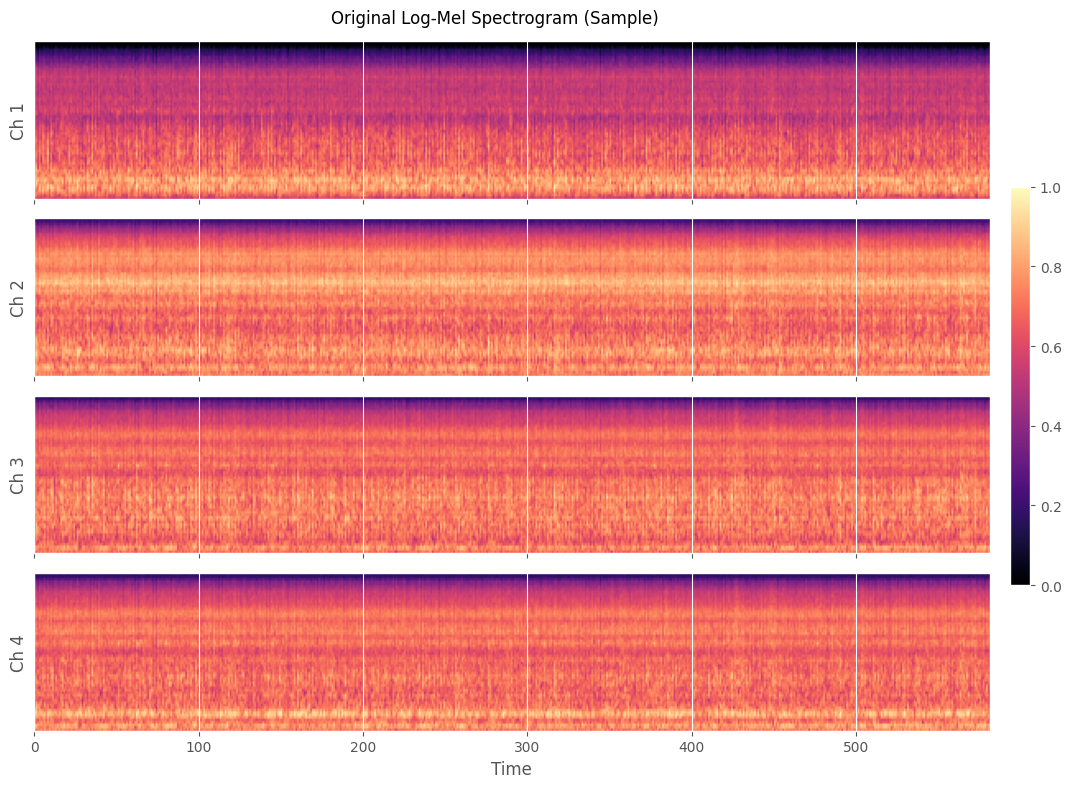

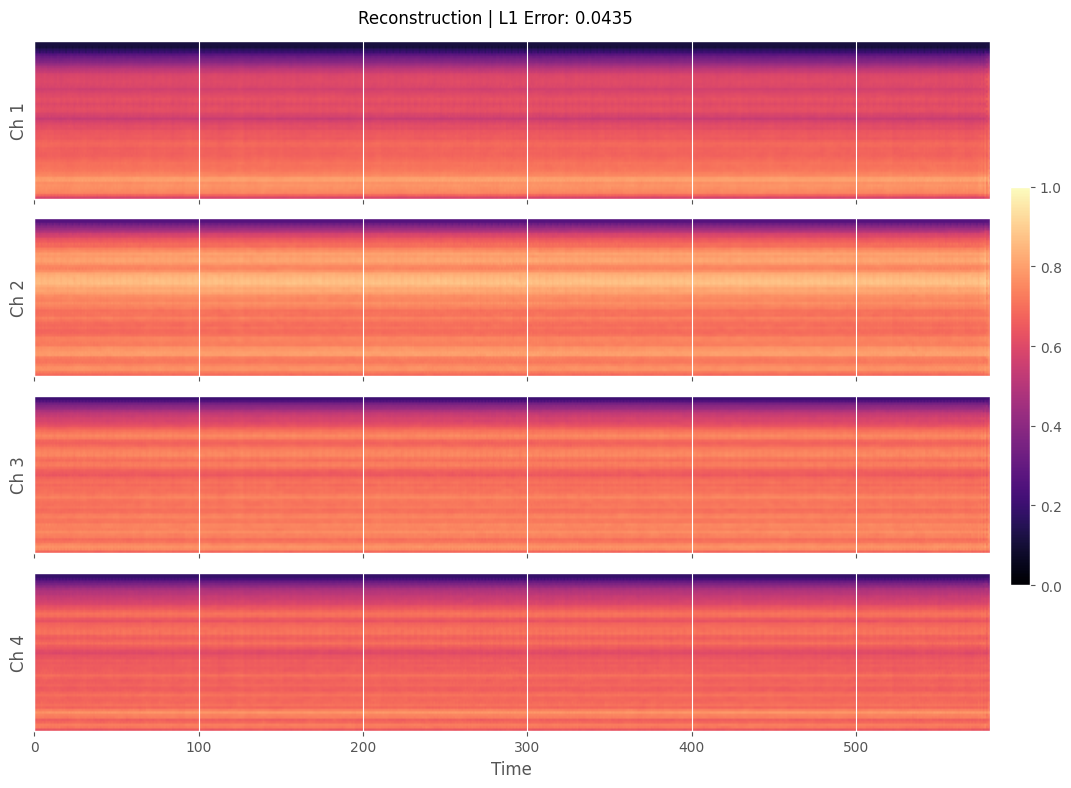

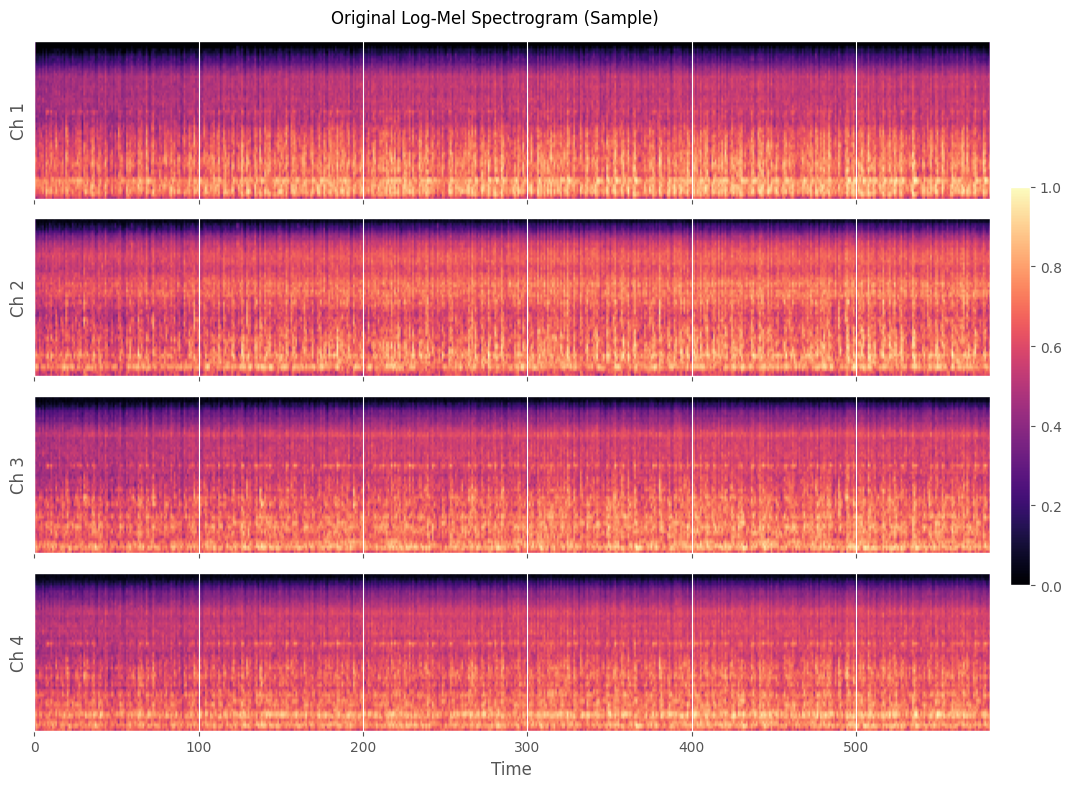

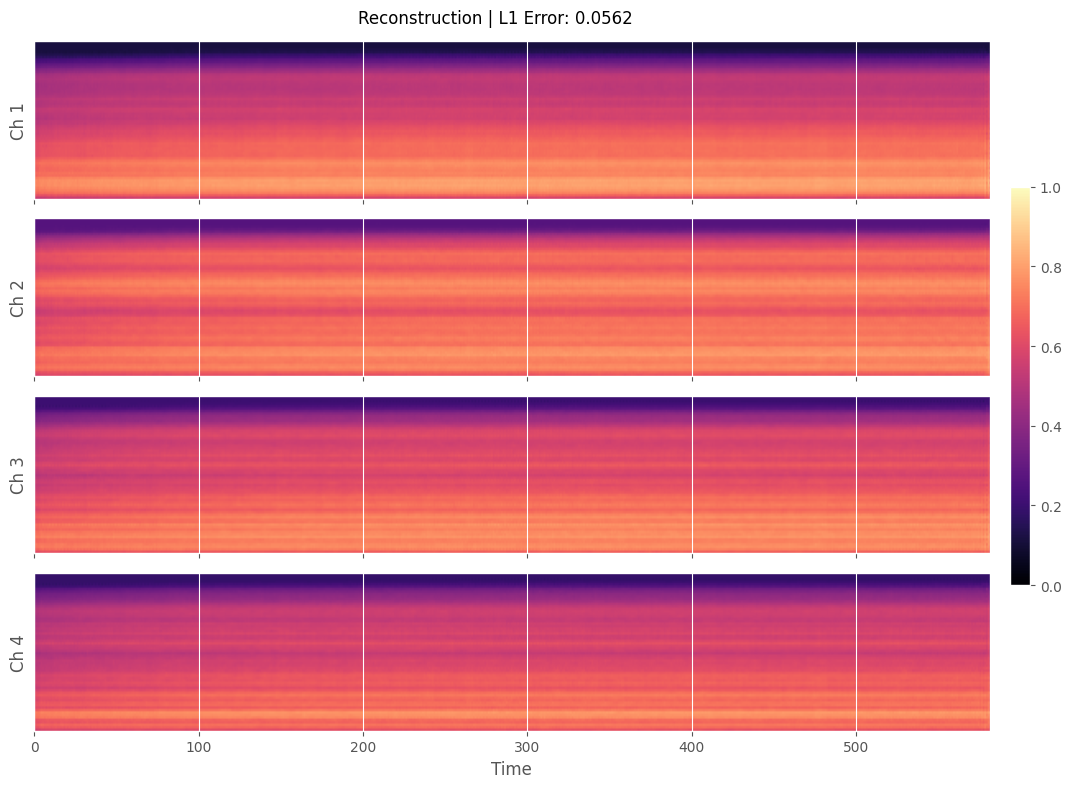

In [14]:
# Visual checks on one normal sample and one anomaly sample using helper plot function.
if "test_loaders" not in globals():
    raise RuntimeError("test_loaders is missing. Run the loader setup cells first.")
if "model" not in globals():
    raise RuntimeError("model is missing. Run the final training or model-loading cells first.")

test_normal_loader = test_loaders["all_cases"]["test_normal_loader"]
test_anom_loader = test_loaders["all_cases"]["test_anom_loader"]

plot_one_reconstruction(model, iter(test_normal_loader), device)
plot_one_reconstruction(model, iter(test_anom_loader), device)